In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as img
import os
import cv2

In [3]:
os.listdir('/kaggle/input/sports-image-classification/dataset/')

['sample_submission.csv', 'train.csv', 'test.csv', 'test', 'train']

In [4]:
df_train = pd.read_csv('/kaggle/input/sports-image-classification/dataset/train.csv')
df_test = pd.read_csv('/kaggle/input/sports-image-classification/dataset/test.csv')

In [5]:
data = {
    'Cricket':0,
    'Wrestling':1,
    'Tennis':2,
    'Badminton':3,
    'Soccer':4,
    'Swimming':5,
    'Karate':6
}

In [6]:
dict_train = {}
for index,row in df_train.iterrows():
    image_name = row[0]
    label_name = row[1]
    dict_train[image_name] = data[label_name]

/tmp/ipykernel_55/3408249791.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  image_name = row[0]
/tmp/ipykernel_55/3408249791.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label_name = row[1]


In [7]:
X_train = []
y_train = []
for i in os.listdir('/kaggle/input/sports-image-classification/dataset/train'):
    try:
        image = img.imread(f'/kaggle/input/sports-image-classification/dataset/train/{i}')
        image = cv2.resize(image, (150,150))
        if len(image.shape) == 3:
            image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        image = image.reshape(150,150,1)
        image = image / 255
        X_train.append(image)
        y_train.append(dict_train[i])
    except:
        print(j)
X_train = np.array(X_train)
y_train = np.array(y_train)

In [8]:
X_test = []
for i in os.listdir('/kaggle/input/sports-image-classification/dataset/test'):
    try:
        image = img.imread(f'/kaggle/input/sports-image-classification/dataset/test/{i}')
        image = cv2.resize(image, (150,150))
        if len(image.shape) == 3:
            image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        image = image.reshape(150,150,1)
        image = image / 255
        X_test.append(image)
    except:
        print(j)

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [11]:
from keras import Sequential
from keras.layers import Conv2D, Flatten, MaxPooling2D, Dense, Dropout
from keras.optimizers import Adam

2026-03-20 10:19:35.271635: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774001975.536928      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774001975.603237      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774001976.188036      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774001976.188075      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774001976.188078      55 computation_placer.cc:177] computation placer alr

In [12]:
from keras.utils import to_categorical

In [13]:
y_train = to_categorical(y_train, num_classes=7)
y_val = to_categorical(y_val, num_classes=7)

In [14]:
y_train

array([[0., 0., 1., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]])

In [15]:
model = Sequential()

model.add(Conv2D(filters=64, kernel_size=(4,4), input_shape=(150,150,1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(units=128, activation=('relu')))
model.add(Dropout(0.4))
model.add(Dense(units=64, activation=('relu')))
model.add(Dropout(0.4))
model.add(Dense(units=64, activation=('relu')))
model.add(Dropout(0.3))
model.add(Dense(units=32, activation=('relu')))
model.add(Dense(units=7, activation=('softmax')))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-20 10:20:03.074403: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [16]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [17]:
model.fit(X_train,y_train, validation_data=(X_val,y_val), epochs=10, batch_size=32)

Epoch 1/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 196s 938ms/step - accuracy: 0.1996 - loss: 2.1506 - val_accuracy: 0.2977 - val_loss: 1.7741
Epoch 2/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 191s 928ms/step - accuracy: 0.2800 - loss: 1.7809 - val_accuracy: 0.3396 - val_loss: 1.6522
Epoch 3/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 192s 934ms/step - accuracy: 0.3793 - loss: 1.5880 - val_accuracy: 0.4471 - val_loss: 1.5212
Epoch 4/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 194s 944ms/step - accuracy: 0.4663 - loss: 1.4231 - val_accuracy: 0.4502 - val_loss: 1.4356
Epoch 5/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 192s 930ms/step - accuracy: 0.5231 - loss: 1.2601 - val_accuracy: 0.5109 - val_loss: 1.3588
Epoch 6/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 191s 929ms/step - accuracy: 0.5743 - loss: 1.1421 - val_accuracy: 0.5182 - val_loss: 1.3488
Epoch 7/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 194s 943ms/step - accuracy: 0.6204 - loss: 1.0512 - val_accuracy: 0.5425 - val_loss: 1.3505
Epoch 8/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 194s 941ms/step - accuracy: 0.6644 -

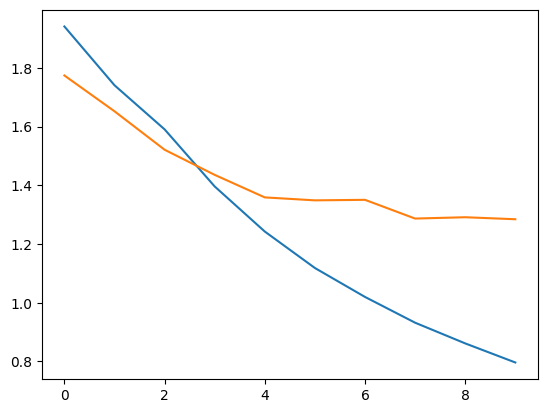

In [18]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])